In [1]:
!pip show cellphonedb

Name: cellphonedb
Version: 5.0.1
Summary: Inferring cell-cell communication.
Home-page: https://github.com/ventolab/cellphonedb
Author: The CellPhoneDB development team
Author-email: contact@cellphonedb.org
License: MIT
Location: /opt/anaconda3/envs/cpdb/lib/python3.8/site-packages
Requires: anndata, geosketch, ktplotspy, numpy, numpy-groupies, pandas, pytest, requests, scanpy, scikit-learn, tqdm
Required-by: 


In [2]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import cellphonedb

# Set up CellPhoneDB input and output folders
data_dir = "./cpdb_inputs"
out_dir = "./cpdb_outputs_m1_m13"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

# Read the data and cellular map
adata = sc.read_h5ad("/Users/jingyuandu/Desktop/Dissertation Project/zhang_processed.h5ad")
print("Number of cells and genes in the data:", adata.shape)
print("Column names in obs:", adata.obs.columns.tolist())


# Export metadata file
meta = pd.DataFrame({
    'cell': adata.obs_names,
    'cell_type': adata.obs['Sub_ClusterID']  
})
meta_path = os.path.join(data_dir, "metadata.tsv")
meta.to_csv(meta_path, sep='\t', index=False)

# Export Counts File (h5ad format)
counts_path = os.path.join(data_dir, "counts_log1p.h5ad")
## Use adata.X and the new meta to construct the object for export
adata_cpdb = sc.AnnData(X=adata.X, obs=meta.set_index('cell'), var=adata.var)
adata_cpdb.write_h5ad(counts_path)

print("Metadata and Counts files saved for CellPhoneDB!")

Number of cells and genes in the data: (43817, 2000)
Column names in obs: ['Sample_BarcodeID', 'Sample', 'Tissue', 'Platform', 'raw.nUMI', 'raw.nGene', 'filter.nUMI', 'filter.nGene', 'ribo.per', 'raw.nCD', 'raw.nTF', 'raw.nCyt', 'raw.nLR', 'Global_Cluster', 'Sub_Cluster', 'Sub_ClusterID', 'Global_tSNE_1', 'Global_tSNE_2', 'Sub_tSNE_1', 'Sub_tSNE_2', 'integrated.Global_tSNE_1', 'integrated.Global_tSNE_2']
Metadata and Counts files saved for CellPhoneDB!


In [4]:
import os
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method
from cellphonedb.utils import db_utils

db_dir = "./cpdb_db"
out_dir = "./cpdb_outputs"
data_dir = "./cpdb_inputs"

meta_path = os.path.join(data_dir, "metadata.tsv")
counts_path = os.path.join(data_dir, "counts_log1p.h5ad")

os.makedirs(db_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)


# Download CellPhoneDB v5 database
db_path = os.path.join(db_dir, "cellphonedb.zip")
if not os.path.exists(db_path):
    print("Downloading CellPhoneDB v5 database...")
    db_utils.download_database(db_dir, "v5.0.0")

# Run Method 2
cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = db_path,
    meta_file_path = meta_path,
    counts_file_path = counts_path,
    counts_data = 'hgnc_symbol',     # Gene Name Type
    iterations = 1000,               # Number of permutation tests
    threshold = 0.1,                 # Cell expression proportion threshold (10%)
    threads = 8,                     # Configure multi-threaded acceleration
    debug_seed = 42,
    result_precision = 3,
    pvalue = 0.05,
    separator = '|',
    score_interactions = True,      
    output_path = out_dir
)

print("CellPhoneDB v5 analysis completed!")

Reading user files...
The following user files were loaded successfully:
./cpdb_inputs/counts_log1p.h5ad
./cpdb_inputs/metadata.tsv
[ ][CORE][26/08/26-12:18:46][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:8 Precision:3
[ ][CORE][26/08/26-12:18:46][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][26/08/26-12:18:47][INFO] Running Real Analysis
[ ][CORE][26/08/26-12:18:47][INFO] Running Statistical Analysis


100%|██████████████████████████████████████| 1000/1000 [01:54<00:00,  8.71it/s]

[ ][CORE][26/08/26-12:20:42][INFO] Building Pvalues result


[ ][CORE][26/08/26-12:20:42][INFO] Building results
[ ][CORE][26/08/26-12:20:42][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████| 38/38 [00:00<00:00, 104.29it/s]

[ ][CORE][26/08/26-12:20:43][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|█████████████████████████████████████████| 38/38 [00:00<00:00, 384.62it/s]


[ ][CORE][26/08/26-12:20:43][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|█████████████████████████████████████| 1444/1444 [00:08<00:00, 168.72it/s]


Saved deconvoluted to ./cpdb_outputs/statistical_analysis_deconvoluted_08_26_2026_122052.txt
Saved deconvoluted_percents to ./cpdb_outputs/statistical_analysis_deconvoluted_percents_08_26_2026_122052.txt
Saved means to ./cpdb_outputs/statistical_analysis_means_08_26_2026_122052.txt
Saved pvalues to ./cpdb_outputs/statistical_analysis_pvalues_08_26_2026_122052.txt
Saved significant_means to ./cpdb_outputs/statistical_analysis_significant_means_08_26_2026_122052.txt
Saved interaction_scores to ./cpdb_outputs/statistical_analysis_interaction_scores_08_26_2026_122052.txt
CellPhoneDB v5 analysis completed!


In [5]:
import pandas as pd
import os
import glob

# Load results from Method 2
sig_means_files = glob.glob("./**/statistical_analysis_significant_means*.txt", recursive=True)
scores_files = glob.glob("./**/statistical_analysis_interaction_scores*.txt", recursive=True)

sig_means_file = max(sig_means_files, key=os.path.getctime)
scores_file = max(scores_files, key=os.path.getctime)

print(f"Loaded Significant Means (for presence/absence): {os.path.basename(sig_means_file)}")
print(f"Loaded Interaction Scores (for specificity ranking): {os.path.basename(scores_file)}")

sig_means_df = pd.read_csv(sig_means_file, sep='\t')
scores_df = pd.read_csv(scores_file, sep='\t')

# Define the interacting cell pairs
tumor_cluster = "Tumor_cells" 
pair_c1qc = f"{tumor_cluster}|hM12"
pair_spp1 = f"{tumor_cluster}|hM13"

if pair_spp1 not in scores_df.columns or pair_c1qc not in scores_df.columns:
    print(f"\n Error: Columns '{pair_spp1}' or '{pair_c1qc}' not found!")
    print("Available pairs (first 10):", [c for c in scores_df.columns if '|' in c][:10])
else:
    # Specificity Score Analysis
    ## We filter for Score > 50 and sort in descending order to find the top specific drivers.
    spp1_specific = scores_df[scores_df[pair_spp1] > 50].copy()
    spp1_specific = spp1_specific[['interacting_pair', pair_spp1, pair_c1qc]].sort_values(by=pair_spp1, ascending=False)
    
    print("\n Top Highly Specific Interactions for SPP1+ TAMs (Ranked by Specificity Score):")
    print(spp1_specific.head(10))


    # Significant Means Analysis (Exclusive)
    # Based on Method 2, non-significant interactions (p > 0.05) are replaced with NaN.
    # Exclusive = Significant in SPP1+ (notnull) AND Non-significant/Absent in C1QC+ (isnull).
    exclusive_spp1 = sig_means_df[sig_means_df[pair_spp1].notnull() & sig_means_df[pair_c1qc].isnull()].copy()
    exclusive_spp1 = exclusive_spp1[['interacting_pair', pair_spp1]].sort_values(by=pair_spp1, ascending=False)
    
    print("\n Exclusive Interactions in SPP1+ TAMs (Significant here, but NaN in C1QC+):")
    print(exclusive_spp1.head(10))

Loaded Significant Means (for presence/absence): statistical_analysis_significant_means_08_26_2026_122052.txt
Loaded Interaction Scores (for specificity ranking): statistical_analysis_interaction_scores_08_26_2026_122052.txt

 Error: Columns 'Tumor_cells|hM13' or 'Tumor_cells|hM12' not found!
Available pairs (first 10): ['hB01|hB01', 'hB01|hB02', 'hB01|hB03', 'hB01|hB04', 'hB01|hB05', 'hB01|hI01', 'hB01|hI02', 'hB01|hI04', 'hB01|hM01', 'hB01|hM02']


Data cleaning complete!


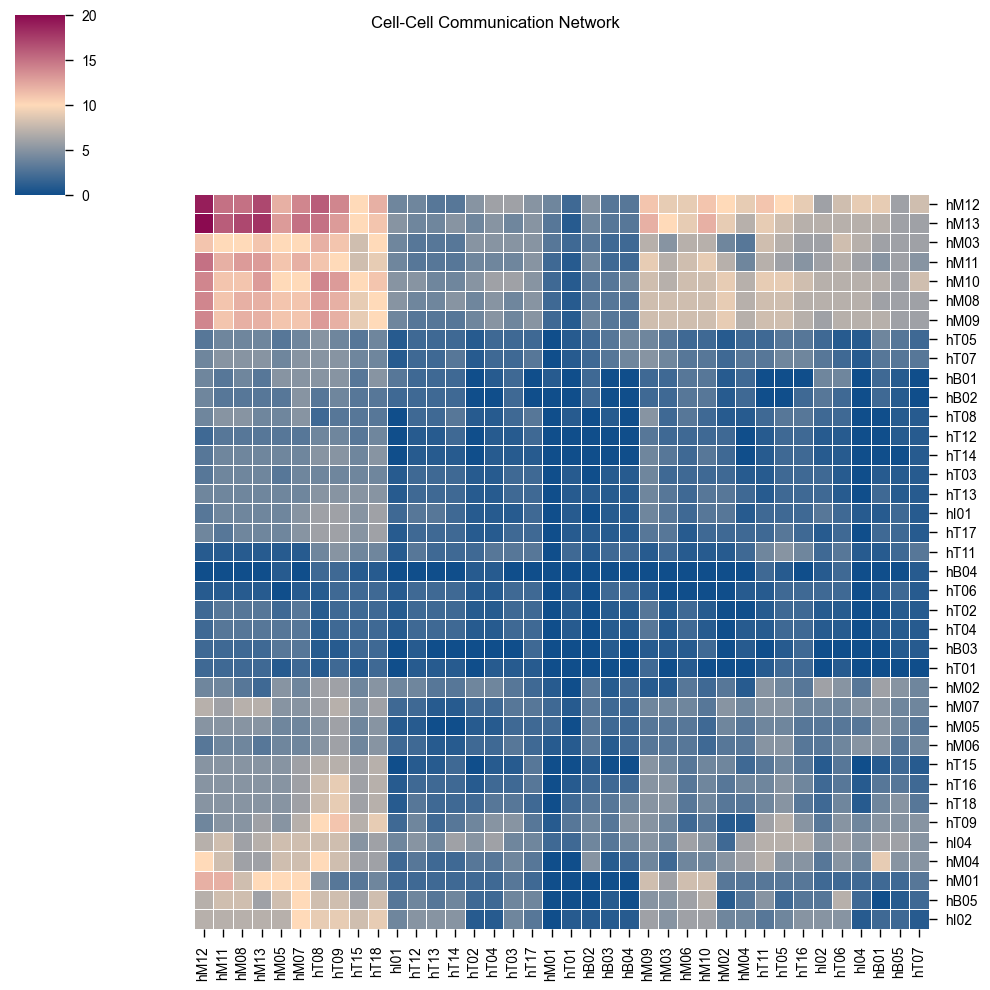

In [6]:
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
import os

out_dir = "./cpdb_outputs"

# Read files
pvals_path = os.path.join(out_dir, "/Users/jingyuandu/Desktop/Dissertation Project/cpdb_outputs/statistical_analysis_pvalues_07_29_2026_113406.txt")
means_path = os.path.join(out_dir, "/Users/jingyuandu/Desktop/Dissertation Project/cpdb_outputs/statistical_analysis_means_07_29_2026_113406.txt")

pvals_df = pd.read_csv(pvals_path, sep='\t')
means_df = pd.read_csv(means_path, sep='\t')

# Clean missing values in string columns
columns_to_fix = ['interacting_pair', 'partner_a', 'partner_b', 'gene_a', 'gene_b']
for col in columns_to_fix:
    if col in pvals_df.columns:
        pvals_df[col] = pvals_df[col].fillna('Unknown').astype(str)
        means_df[col] = means_df[col].fillna('Unknown').astype(str)

# Force numeric conversion for all columns containing cell pairs (with '|')
pair_cols = [c for c in pvals_df.columns if '|' in c]
pvals_df[pair_cols] = pvals_df[pair_cols].apply(pd.to_numeric, errors='coerce').fillna(1.0)
means_df[pair_cols] = means_df[pair_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)

print("Data cleaning complete!")

# Generate heatmap
kpy.plot_cpdb_heatmap(
    pvals = pvals_df,
    figsize = (10, 10),
    title = "Cell-Cell Communication Network",
    symmetrical = False
)
plt.show()

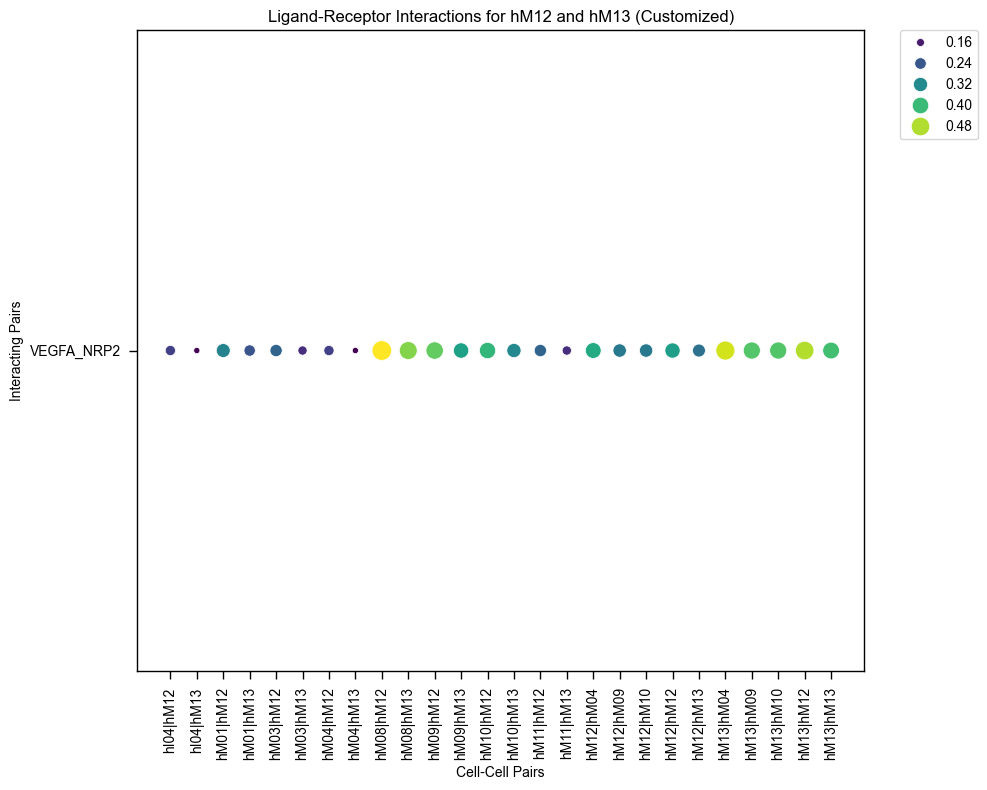

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

out_dir = "./cpdb_outputs"
pvals_df = pd.read_csv(os.path.join(out_dir, "/Users/jingyuandu/Desktop/Dissertation Project/cpdb_outputs/statistical_analysis_pvalues_07_29_2026_113406.txt"), sep='\t')
means_df = pd.read_csv(os.path.join(out_dir, "/Users/jingyuandu/Desktop/Dissertation Project/cpdb_outputs/statistical_analysis_means_07_29_2026_113406.txt"), sep='\t')


key_genes = ["SPP1", "CD44", "VEGFA", "C1QA", "C1QC", "MMP2", "SDC2", "TGFB1"]

# Filter rows containing these genes
sub_pvals = pvals_df[pvals_df['gene_a'].isin(key_genes) | pvals_df['gene_b'].isin(key_genes)]
sub_means = means_df[means_df['gene_a'].isin(key_genes) | means_df['gene_b'].isin(key_genes)]


pair_cols = [c for c in sub_pvals.columns if '|' in c]
pvals_long = sub_pvals.melt(id_vars=['interacting_pair'], value_vars=pair_cols, var_name='cell_pair', value_name='pval')
means_long = sub_means.melt(id_vars=['interacting_pair'], value_vars=pair_cols, var_name='cell_pair', value_name='mean')

plot_df = pd.merge(pvals_long, means_long, on=['interacting_pair', 'cell_pair'])

# Only filter out cell pairs associated with hM12 or hM13
plot_df = plot_df[plot_df['cell_pair'].str.contains('hM12|hM13')]
plot_df['pval'] = pd.to_numeric(plot_df['pval'], errors='coerce').fillna(1.0)
plot_df['mean'] = pd.to_numeric(plot_df['mean'], errors='coerce').fillna(0.0)

# Creating a custom bubble chart using Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=plot_df[plot_df['pval'] < 0.05],
    x='cell_pair',
    y='interacting_pair',
    size='mean',
    hue='mean',
    palette='viridis',
    sizes=(20, 200)
)
plt.xticks(rotation=90)
plt.title("Ligand-Receptor Interactions for hM12 and hM13 (Customized)")
plt.xlabel("Cell-Cell Pairs")
plt.ylabel("Interacting Pairs")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

In [8]:
adata.write_h5ad("/Users/jingyuandu/Desktop/Dissertation Project/zhang_processed.h5ad")

In [9]:
import pandas as pd
import os

out_dir = "/Users/jingyuandu/Desktop/Dissertation Project/cpdb_outputs"

# Method 3
# Find and read files in the folder that contain 'deconvoluted' in their names
for f in os.listdir(out_dir):
    if "deconvoluted" in f and f.endswith(".txt") and "percents" not in f:
        print(f"the Deconvolution master file: {f}")
        decon_df = pd.read_csv(os.path.join(out_dir, f), sep='\t')
        display(decon_df.head(10))

the Deconvolution master file: statistical_analysis_deconvoluted_07_29_2026_113025.txt


,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,hB01,hB02,hB03,...,hT08,hT09,hT11,hT12,hT13,hT14,hT15,hT16,hT17,hT18
0,LIPA,P38571,True,LICH_HUMAN,Cholesterol_byLIPA,CPI-CS0406B0B69,LIPA,0.039,0.036,0.060,...,0.095,0.078,0.051,0.034,0.033,0.053,0.040,0.066,0.058,0.059
1,LIPA,P38571,True,LICH_HUMAN,Cholesterol_byLIPA,CPI-CS0F51152EA,LIPA,0.039,0.036,0.060,...,0.095,0.078,0.051,0.034,0.033,0.053,0.040,0.066,0.058,0.059
2,LTA4H,P09960,True,LKHA4_HUMAN,LeukotrieneB4_byLTA4H,CPI-CS047D9C0D7,LTA4H,0.119,0.112,0.190,...,0.114,0.170,0.118,0.050,0.042,0.075,0.068,0.078,0.065,0.069
3,AKR1C3,P42330,True,AK1C3_HUMAN,ProstaglandinD2_byAKR1C3,CPI-CS0F3C15BCC,AKR1C3,0.002,0.001,0.001,...,0.000,0.010,0.019,0.007,0.007,0.032,0.002,0.001,0.002,0.008
4,PTGDS,P41222,True,PTGDS_HUMAN,PGD2_byPTGDS,CPI-CS0FADCFDB9,PTGDS,0.003,0.006,0.001,...,0.000,0.001,0.000,0.027,0.020,0.088,0.004,0.000,0.003,0.002
5,CADM1,Q9BY67,False,CADM1_HUMAN,NaN,CPI-SS0889E281D,CADM1,0.297,0.123,0.003,...,0.075,0.041,0.053,0.005,0.009,0.015,0.009,0.003,0.002,0.035
6,CRTAM,O95727,False,CRTAM_HUMAN,NaN,CPI-SS0C9696AAA,CRTAM,0.006,0.006,0.006,...,0.000,0.093,0.005,0.124,0.151,0.060,0.415,0.250,0.301,0.245
7,COL18A1,P39060,False,COIA1_HUMAN,NaN,CPI-SC0C739EDCE,COL18A1,0.018,0.014,0.004,...,0.015,0.014,0.008,0.003,0.001,0.000,0.012,0.029,0.015,0.019
8,COL19A1,Q14993,False,COJA1_HUMAN,NaN,CPI-SC079D293A2,COL19A1,0.002,0.002,0.133,...,0.010,0.006,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000
9,COL1A1,P02452,False,CO1A1_HUMAN,NaN,CPI-SC08DBCCFF0,COL1A1,0.003,0.006,0.002,...,0.018,0.005,0.001,0.000,0.000,0.000,0.001,0.000,0.000,0.000


the Deconvolution master file: statistical_analysis_deconvoluted_07_29_2026_113406.txt


,gene_name,uniprot,is_complex,protein_name,complex_name,id_cp_interaction,gene,hB01,hB02,hB03,...,hT08,hT09,hT11,hT12,hT13,hT14,hT15,hT16,hT17,hT18
0,LIPA,P38571,True,LICH_HUMAN,Cholesterol_byLIPA,CPI-CS0406B0B69,LIPA,0.039,0.036,0.060,...,0.095,0.078,0.051,0.034,0.033,0.053,0.040,0.066,0.058,0.059
1,LIPA,P38571,True,LICH_HUMAN,Cholesterol_byLIPA,CPI-CS0F51152EA,LIPA,0.039,0.036,0.060,...,0.095,0.078,0.051,0.034,0.033,0.053,0.040,0.066,0.058,0.059
2,LTA4H,P09960,True,LKHA4_HUMAN,LeukotrieneB4_byLTA4H,CPI-CS047D9C0D7,LTA4H,0.119,0.112,0.190,...,0.114,0.170,0.118,0.050,0.042,0.075,0.068,0.078,0.065,0.069
3,AKR1C3,P42330,True,AK1C3_HUMAN,ProstaglandinD2_byAKR1C3,CPI-CS0F3C15BCC,AKR1C3,0.002,0.001,0.001,...,0.000,0.010,0.019,0.007,0.007,0.032,0.002,0.001,0.002,0.008
4,PTGDS,P41222,True,PTGDS_HUMAN,PGD2_byPTGDS,CPI-CS0FADCFDB9,PTGDS,0.003,0.006,0.001,...,0.000,0.001,0.000,0.027,0.020,0.088,0.004,0.000,0.003,0.002
5,CADM1,Q9BY67,False,CADM1_HUMAN,NaN,CPI-SS0889E281D,CADM1,0.297,0.123,0.003,...,0.075,0.041,0.053,0.005,0.009,0.015,0.009,0.003,0.002,0.035
6,CRTAM,O95727,False,CRTAM_HUMAN,NaN,CPI-SS0C9696AAA,CRTAM,0.006,0.006,0.006,...,0.000,0.093,0.005,0.124,0.151,0.060,0.415,0.250,0.301,0.245
7,COL18A1,P39060,False,COIA1_HUMAN,NaN,CPI-SC0C739EDCE,COL18A1,0.018,0.014,0.004,...,0.015,0.014,0.008,0.003,0.001,0.000,0.012,0.029,0.015,0.019
8,COL19A1,Q14993,False,COJA1_HUMAN,NaN,CPI-SC079D293A2,COL19A1,0.002,0.002,0.133,...,0.010,0.006,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000
9,COL1A1,P02452,False,CO1A1_HUMAN,NaN,CPI-SC08DBCCFF0,COL1A1,0.003,0.006,0.002,...,0.018,0.005,0.001,0.000,0.000,0.000,0.001,0.000,0.000,0.000


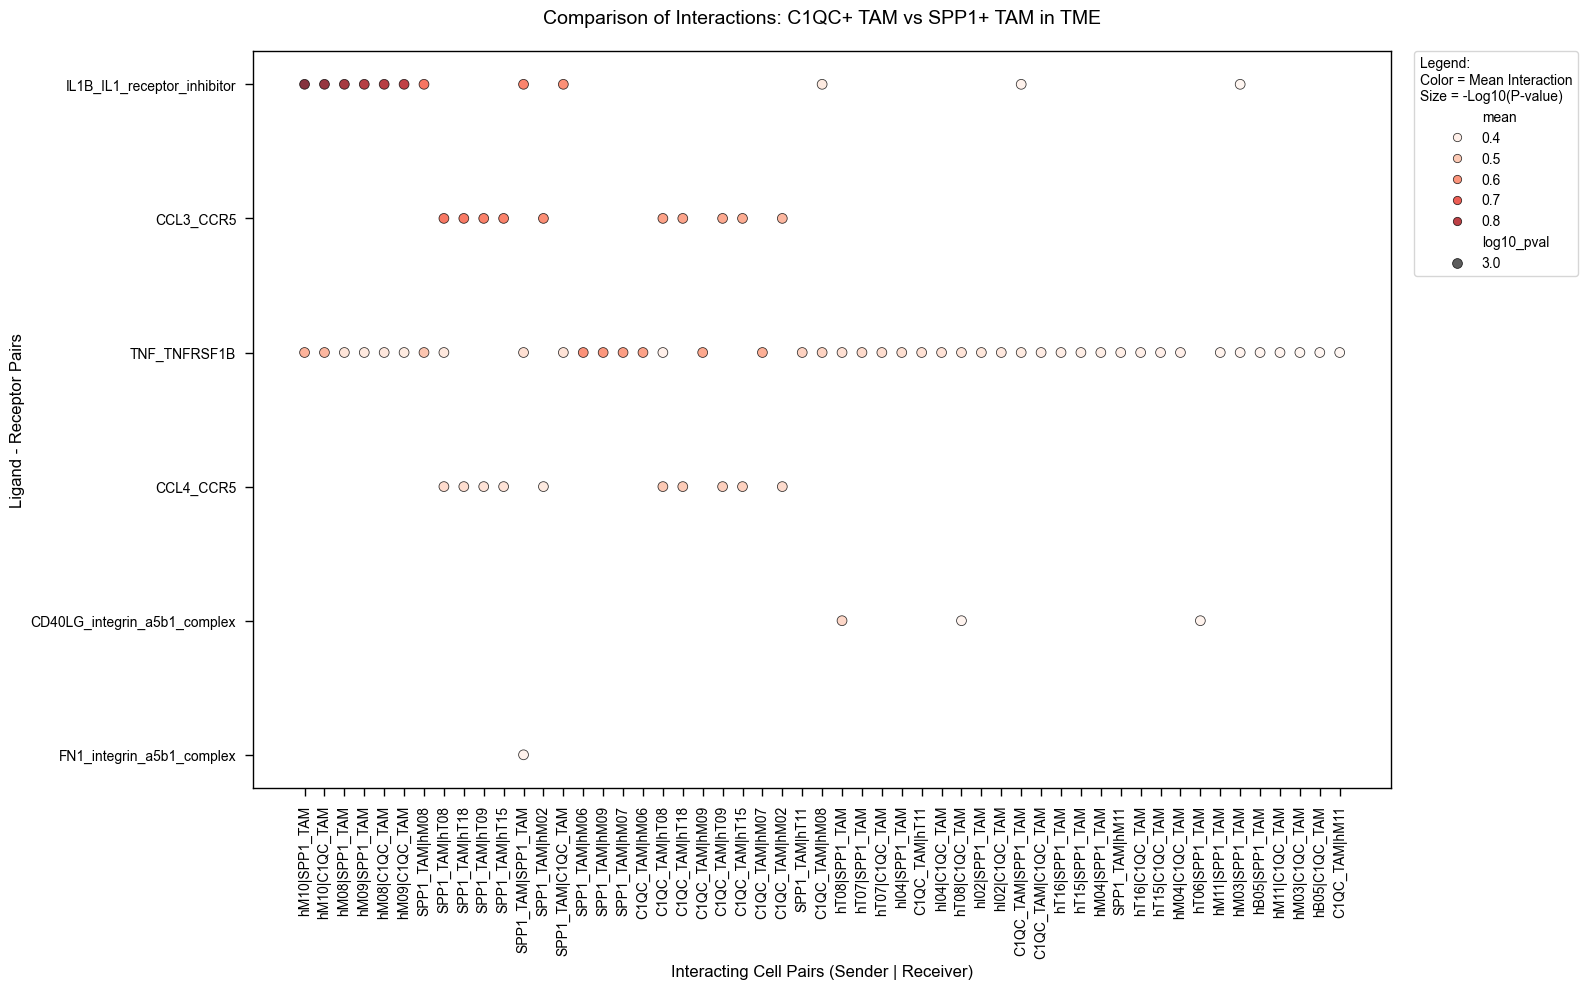

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

key_genes = ["CXCL10", "CXCR3", "CCL4", "CCR5", "CD40", "CD40LG", 
             "SPP1", "CD44", "C1QA", "C1QB", "C1QC", "FN1", "ITGAV", "IL1B", "TNF", "IFNG"]

# Filter for interaction pairs containing these genes
sub_pvals = pvals_df[pvals_df['gene_a'].isin(key_genes) | pvals_df['gene_b'].isin(key_genes)]
sub_means = means_df[means_df['gene_a'].isin(key_genes) | means_df['gene_b'].isin(key_genes)]

pair_cols = [c for c in sub_pvals.columns if '|' in c]
pvals_long = sub_pvals.melt(id_vars=['interacting_pair'], value_vars=pair_cols, var_name='cell_pair', value_name='pval')
means_long = sub_means.melt(id_vars=['interacting_pair'], value_vars=pair_cols, var_name='cell_pair', value_name='mean')

plot_df = pd.merge(pvals_long, means_long, on=['interacting_pair', 'cell_pair'])

# Filter for sender or receiver is hM12 or hM13
plot_df = plot_df[plot_df['cell_pair'].str.contains('hM12|hM13')]


plot_df['pval'] = pd.to_numeric(plot_df['pval'], errors='coerce').fillna(1.0)
plot_df['mean'] = pd.to_numeric(plot_df['mean'], errors='coerce').fillna(0.0)

# Calculate significance and filter insignificant results
plot_df['log10_pval'] = -np.log10(plot_df['pval'] + 1e-3)
plot_df_sig = plot_df[plot_df['pval'] < 0.05].copy()


plot_df_sig['cell_pair'] = plot_df_sig['cell_pair'].str.replace('hM12', 'C1QC_TAM')
plot_df_sig['cell_pair'] = plot_df_sig['cell_pair'].str.replace('hM13', 'SPP1_TAM')

# Draw the bubble plots
if plot_df_sig.empty:
    print("No significant interaction (P < 0.05) was found for the current gene-cell combination.")
else:
    plot_df_sig = plot_df_sig.sort_values(by='mean', ascending=False).head(80)
    
    plt.figure(figsize=(16, 10))
    sns.scatterplot(
        data=plot_df_sig,
        x='cell_pair',           
        y='interacting_pair',    
        size='log10_pval',       
        hue='mean',             
        palette='Reds',
        sizes=(50, 350),
        alpha=0.8,
        edgecolor='black'        
    )

    plt.xticks(rotation=90, fontsize=10)
    plt.title("Comparison of Interactions: C1QC+ TAM vs SPP1+ TAM in TME", fontsize=14, pad=20)
    plt.xlabel("Interacting Cell Pairs (Sender | Receiver)", fontsize=12)
    plt.ylabel("Ligand - Receptor Pairs", fontsize=12)

    
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., 
               title="Legend:\nColor = Mean Interaction\nSize = -Log10(P-value)", fontsize=10)
    
    plt.tight_layout()
    plt.show()

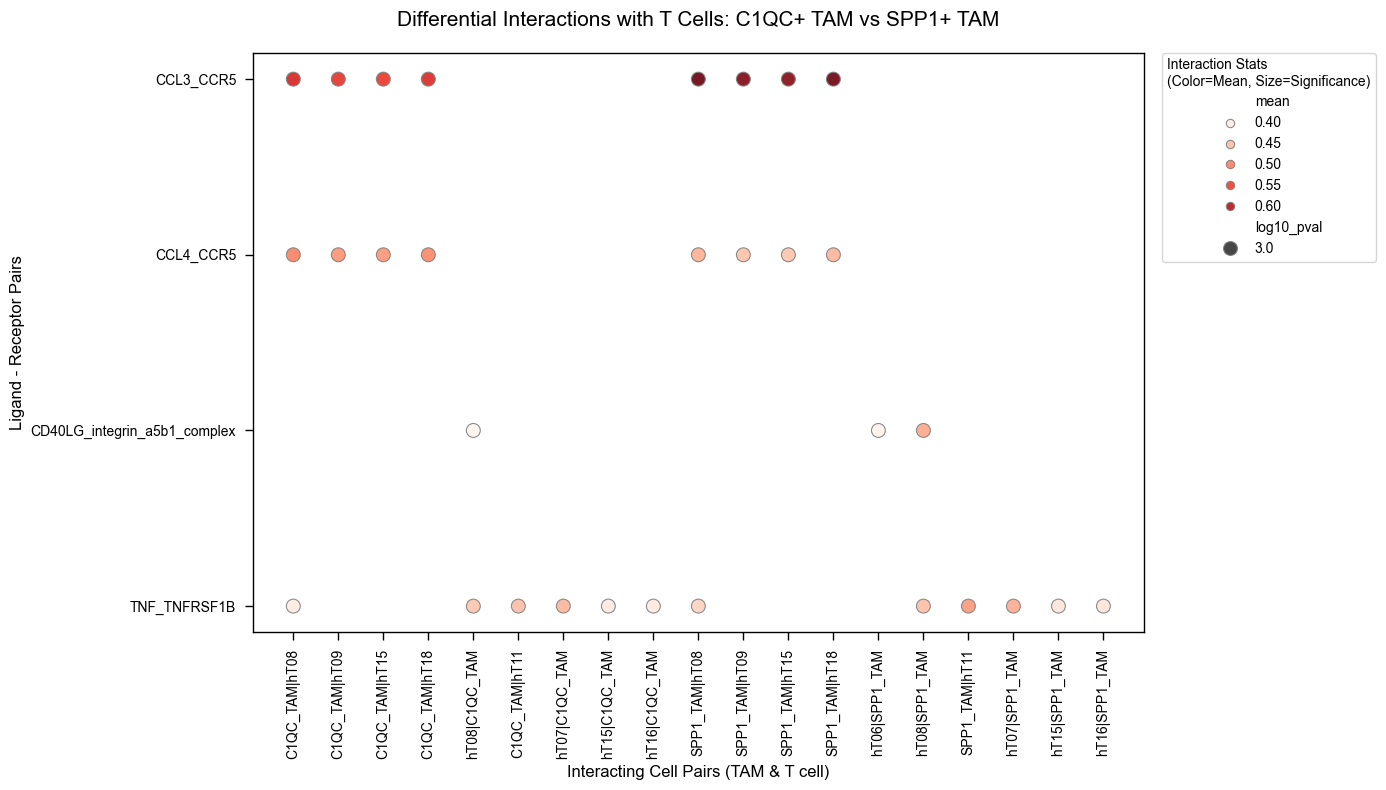

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Keep only the communication between TAMs (C1QC or SPP1) and T cells (starting with hT)
## Find all cell pairs containing 'hT'
t_cell_mask = plot_df_sig['cell_pair'].str.contains('hT')
## Find all cell pairs containing 'TAM'
tam_mask = plot_df_sig['cell_pair'].str.contains('TAM')

## Intersection
plot_df_final = plot_df_sig[t_cell_mask & tam_mask].copy()


# separate the C1QC and SPP1 groups
plot_df_final['TAM_type'] = np.where(plot_df_final['cell_pair'].str.contains('C1QC'), 'C1QC', 'SPP1')
plot_df_final = plot_df_final.sort_values(by=['TAM_type', 'interacting_pair', 'cell_pair'])

# Plot the final version of the bubble chart
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=plot_df_final,
    x='cell_pair',           
    y='interacting_pair',    
    size='log10_pval',       
    hue='mean',              
    palette='Reds',
    sizes=(100, 250),        
    alpha=0.9,
    edgecolor='gray'         
)

plt.xticks(rotation=90, fontsize=10)
plt.title("Differential Interactions with T Cells: C1QC+ TAM vs SPP1+ TAM", fontsize=15, pad=20)
plt.xlabel("Interacting Cell Pairs (TAM & T cell)", fontsize=12)
plt.ylabel("Ligand - Receptor Pairs", fontsize=12)


plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., 
           title="Interaction Stats\n(Color=Mean, Size=Significance)", fontsize=10)

plt.tight_layout()
plt.show()

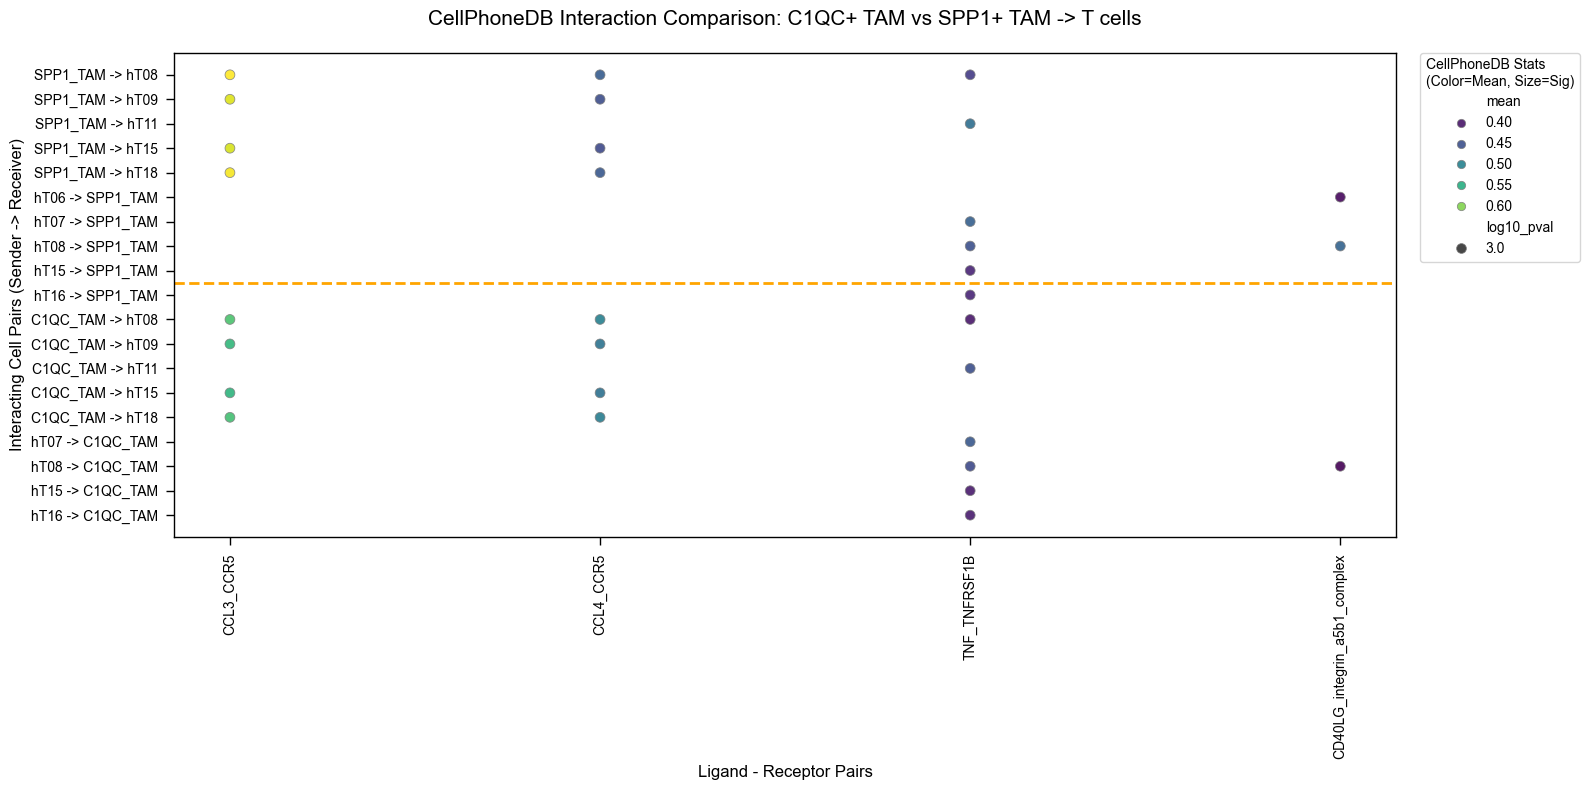

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 提取并过滤数据：仅保留发送方是 hM12 (C1QC) 或 hM13 (SPP1)，接收方是 T 细胞 (hT) 的互作
plot_df_final = plot_df_sig[plot_df_sig['cell_pair'].str.contains('C1QC|SPP1') & 
                            plot_df_sig['cell_pair'].str.contains('hT')].copy()

# 2. 确保细胞名称更加清晰 (Sender -> Receiver 格式)
plot_df_final['cell_pair'] = plot_df_final['cell_pair'].str.replace('|', ' -> ', regex=False)

# 3. 排序逻辑：确保 Y 轴上 C1QC 全部在一起，SPP1 全部在一起
plot_df_final['TAM_type'] = np.where(plot_df_final['cell_pair'].str.contains('C1QC'), 'C1QC', 'SPP1')
# 按 TAM 类型降序排列，这样 C1QC 会在上方，SPP1 会在下方
plot_df_final = plot_df_final.sort_values(by=['TAM_type', 'cell_pair', 'interacting_pair'], ascending=[False, True, True])

# 计算分界线的位置：统计 Y 轴上属于 C1QC 的细胞对数量
unique_cell_pairs = plot_df_final['cell_pair'].unique()
c1qc_count = sum('C1QC' in pair for pair in unique_cell_pairs)

# 4. 开始绘图 (调大画布，X和Y轴对调)
plt.figure(figsize=(16, 8))

sns.scatterplot(
    data=plot_df_final,
    x='interacting_pair',    # X 轴变成配体-受体
    y='cell_pair',           # Y 轴变成细胞对
    size='log10_pval',
    hue='mean',
    palette='viridis',       # 改用类似 CellChat 的冷暖色调，显得更高级
    sizes=(50, 300),
    alpha=0.9,
    edgecolor='gray'
)

# 5. 满足老师要求：画一条水平分割线，把 C1QC 和 SPP1 彻底切开！
# matplotlib 散点图的 Y 轴分类坐标从 0 开始，所以线画在 count - 0.5 的位置
plt.axhline(y=c1qc_count - 0.5, color='orange', linewidth=2, linestyle='--')

# 6. 图表美化
plt.xticks(rotation=90, fontsize=10)
plt.title("CellPhoneDB Interaction Comparison: C1QC+ TAM vs SPP1+ TAM -> T cells", fontsize=15, pad=20)
plt.xlabel("Ligand - Receptor Pairs", fontsize=12)
plt.ylabel("Interacting Cell Pairs (Sender -> Receiver)", fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., 
           title="CellPhoneDB Stats\n(Color=Mean, Size=Sig)", fontsize=10)

plt.tight_layout()
plt.show()